In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data

In [2]:
df = pd.read_csv("data/2019-Oct.csv")

In [3]:
f = df.sample(frac = 0.1,random_state = 42)
del df

# 2. Data structure

In [4]:
print(f.head())

                       event_time event_type  product_id          category_id  \
10257365  2019-10-09 02:46:19 UTC       view    29900078  2059484601444729123   
28875143  2019-10-21 16:17:11 UTC       view     1801805  2053013554415534427   
28709595  2019-10-21 14:42:20 UTC       cart     1004870  2053013555631882655   
3458568   2019-10-03 18:40:22 UTC       view     5701087  2053013553970938175   
25352815  2019-10-19 08:58:51 UTC       view     5300097  2053013563173241677   

                    category_code      brand    price    user_id  \
10257365                      NaN       peda  1647.40  532353313   
28875143     electronics.video.tv      artel   231.60  536042235   
28709595   electronics.smartphone    samsung   284.02  517143806   
3458568   auto.accessories.player        jvc    51.48  556492770   
25352815                      NaN  remington    39.87  561838859   

                                  user_session  
10257365  47059489-3a63-4353-9eab-0e239d5cb5aa  
288751

In [5]:
print(f.columns)

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')


In [6]:
print(f.shape)

(4244876, 9)


In [7]:
print(f.dtypes)

event_time        object
event_type        object
product_id         int64
category_id        int64
category_code     object
brand             object
price            float64
user_id            int64
user_session      object
dtype: object


In [8]:
print(f.isna().sum())

event_time             0
event_type             0
product_id             0
category_id            0
category_code    1350505
brand             611876
price                  0
user_id                0
user_session           0
dtype: int64


In [9]:
print(f["event_type"].value_counts())

event_type
view        4077676
cart          92550
purchase      74650
Name: count, dtype: int64


In [10]:
print(f["event_type"].value_counts())

event_type
view        4077676
cart          92550
purchase      74650
Name: count, dtype: int64


In [11]:
print(f["brand"].value_counts())

brand
samsung             528776
apple               412152
xiaomi              308928
huawei              111993
lucente              65733
                     ...  
kidkraft                 1
xiaoyueliangtoys         1
mdlab                    1
shunxiang                1
mark                     1
Name: count, Length: 3150, dtype: int64


# 3. Exploratory Data Analysis (EDA)

/var/folders/r7/5wz764v55ng1wynsd3fhbk4c0000gn/T/ipykernel_35069/1739575969.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  purchases["hour"] = purchases["event_time"].dt.hour
/var/folders/r7/5wz764v55ng1wynsd3fhbk4c0000gn/T/ipykernel_35069/1739575969.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  purchases["day"] = purchases["event_time"].dt.day


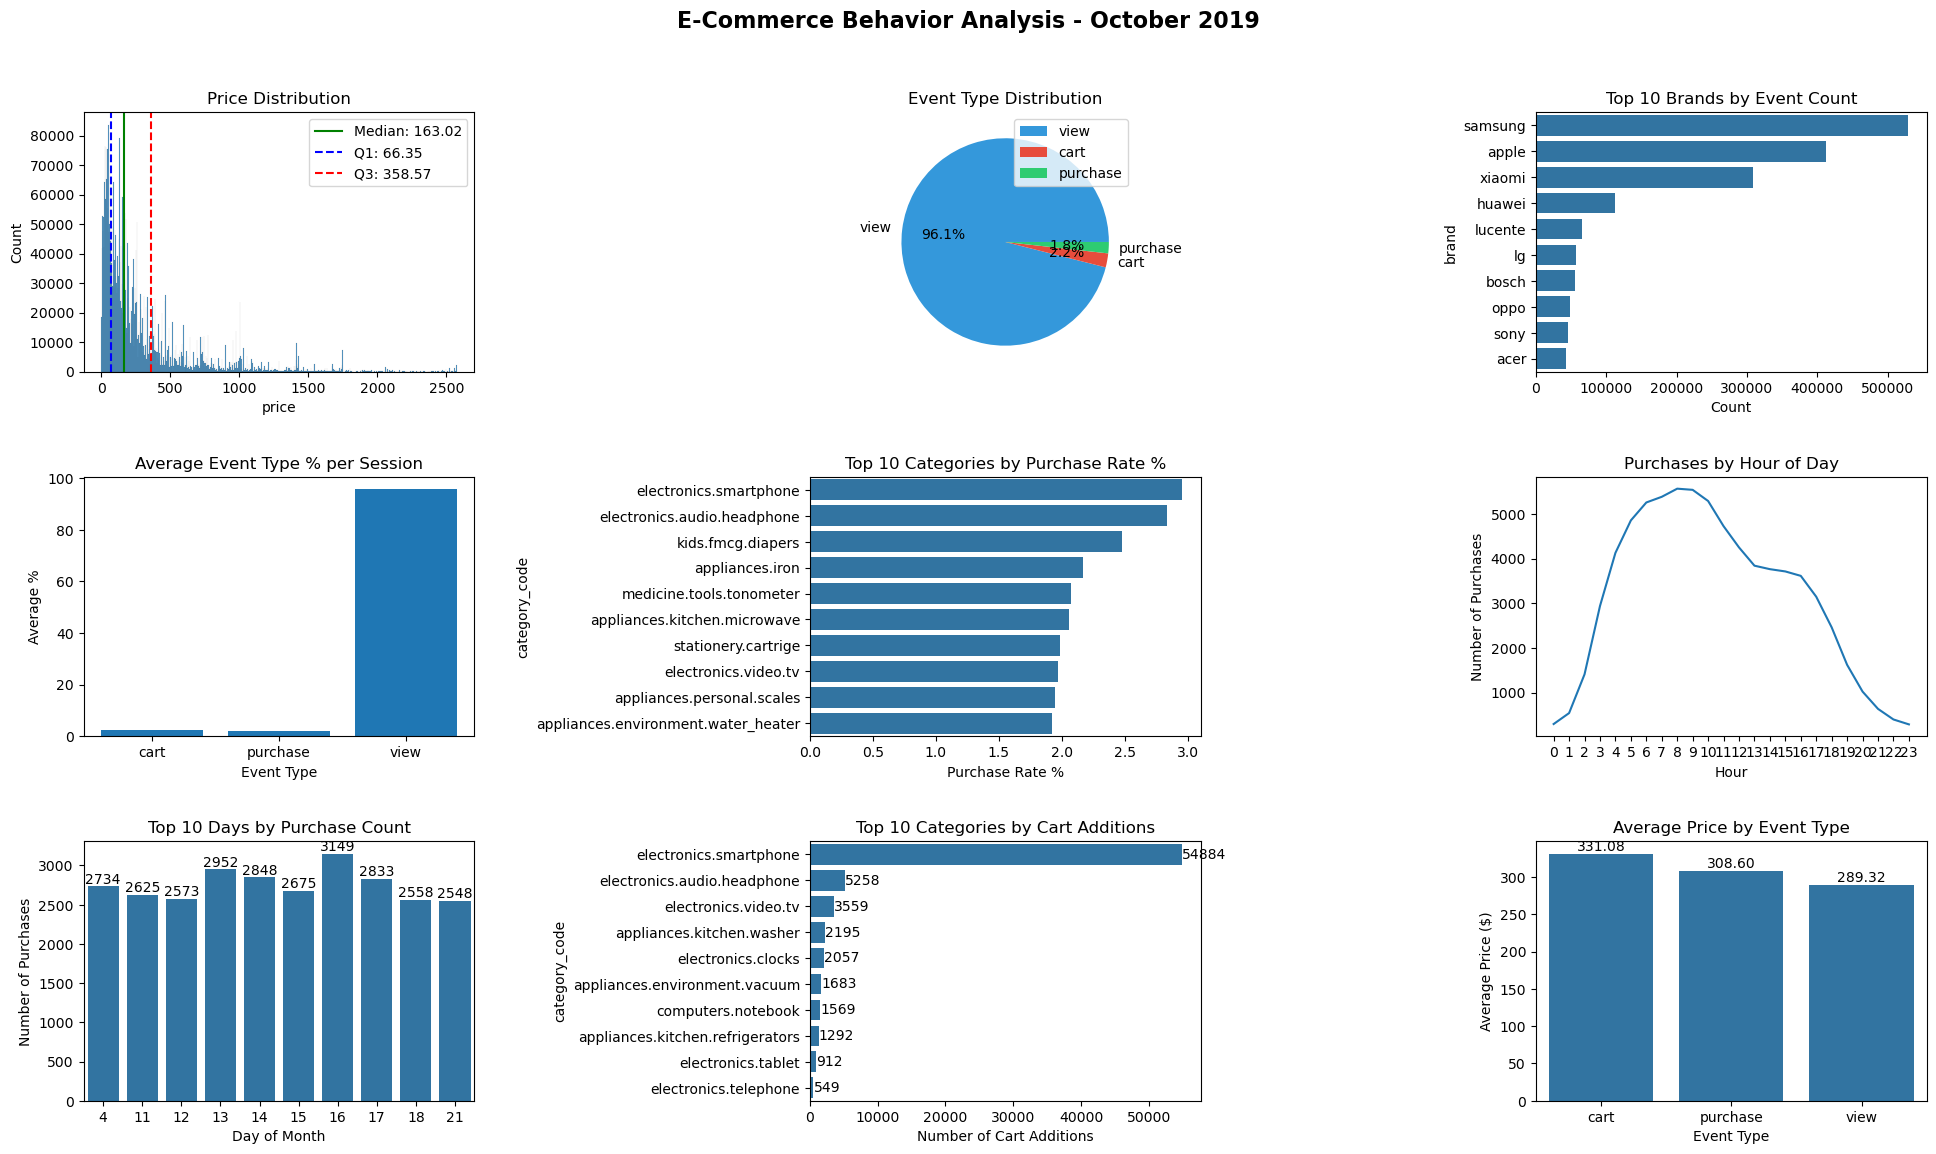

In [12]:
fig,ax = plt.subplots(3,3,figsize = (20,12))
ax = ax.flatten()
fig.suptitle("E-Commerce Behavior Analysis - October 2019", fontsize=16, fontweight='bold')

# 1. price distribution
price_median = f["price"].median()
price_q1 = f["price"].quantile(0.25)
price_q3 = f["price"].quantile(0.75)

sns.histplot(f["price"], ax=ax[0])
ax[0].set_title("Price Distribution")
ax[0].axvline(price_median, color="green", label=f"Median: {price_median:.2f}")
ax[0].axvline(price_q1, color="blue", linestyle="--", label=f"Q1: {price_q1:.2f}")
ax[0].axvline(price_q3, color="red", linestyle="--", label=f"Q3: {price_q3:.2f}")
ax[0].legend()

# 2. Event type
event_counts = f["event_type"].value_counts()
ax[1].pie(event_counts, 
          labels=event_counts.index, 
          autopct='%1.1f%%',
          colors=['#3498db', '#e74c3c', '#2ecc71'])
ax[1].legend()
ax[1].set_title("Event Type Distribution")

# 3. Top 10 brands
top_brands = f["brand"].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, ax=ax[2])
ax[2].set_title("Top 10 Brands by Event Count")
ax[2].set_xlabel("Count")

# 4. Events type per session 
session_stats = f.groupby("user_session")["event_type"].value_counts(normalize=True).unstack(fill_value=0)
session_means = session_stats.mean() * 100

ax[3].bar(session_means.index, session_means.values)
ax[3].set_title("Average Event Type % per Session")
ax[3].set_xlabel("Event Type")
ax[3].set_ylabel("Average %")

# 5. Top 10 Categories by Purchase Rate 
category_purchase = f.groupby("category_code")["event_type"].apply(
    lambda x: (x == "purchase").sum() / len(x) * 100).sort_values(ascending=False).head(10)

sns.barplot(x=category_purchase.values, y=category_purchase.index, ax=ax[4])
ax[4].set_title("Top 10 Categories by Purchase Rate %")
ax[4].set_xlabel("Purchase Rate %")

# 6. Purchases by Hour of Day
f["event_time"] = pd.to_datetime(f["event_time"], utc=True)
purchases = f[f["event_type"] == "purchase"]
purchases["hour"] = purchases["event_time"].dt.hour
hourly_purchases = purchases.groupby("hour").size()
sns.lineplot(x=hourly_purchases.index, y=hourly_purchases.values, ax=ax[5])
ax[5].set_title("Purchases by Hour of Day")
ax[5].set_xlabel("Hour")
ax[5].set_ylabel("Number of Purchases")
ax[5].set_xticks(range(0, 24))

# 7. Purchases by day 
purchases["day"] = purchases["event_time"].dt.day
daily_purchases = purchases.groupby("day").size().sort_values(ascending=False).head(10)
sns.barplot(x=daily_purchases.index, y=daily_purchases.values, ax=ax[6])
ax[6].set_title("Top 10 Days by Purchase Count")
ax[6].set_xlabel("Day of Month")
ax[6].set_ylabel("Number of Purchases")
ax[6].bar_label(ax[6].containers[0], fmt='%d')

# 8. Top 10 Categories by Cart Additions
cart_by_category = f[f["event_type"] == "cart"].groupby("category_code").size().sort_values(ascending=False).head(10)
sns.barplot(x=cart_by_category.values, y=cart_by_category.index, ax=ax[7])
ax[7].set_title("Top 10 Categories by Cart Additions")
ax[7].set_xlabel("Number of Cart Additions")
ax[7].bar_label(ax[7].containers[0], fmt='%d')

# 9. Average Price by Event Type
avg_price_by_event = f.groupby("event_type")["price"].mean()
sns.barplot(x=avg_price_by_event.index, y=avg_price_by_event.values, ax=ax[8])
ax[8].set_title("Average Price by Event Type")
ax[8].set_xlabel("Event Type")
ax[8].set_ylabel("Average Price ($)")
ax[8].bar_label(ax[8].containers[0], fmt='%.2f')

plt.tight_layout(pad=3.0)
plt.show()

### Key Observations

1. `price` distribution is heavily right-skewed, with most values clustered near 0. Median price is \$163 and 75% of products are priced below \$358.
2. 96.1% of customer interactions are views, while only 1.8% result in purchases - indicating a heavily imbalanced dataset.
3. Purchase activity peaks between 10am-12pm, suggesting the morning is the highest conversion window.
4. Electronics categories dominate both cart additions and purchase rates.
5. Cart items average \$308 vs purchases at \$289 - users add expensive items to cart but complete cheaper purchases.

# 4. Preprocessing

In [13]:
purchases = f[f["event_type"] == "purchase"].copy()
f["event_time"] = pd.to_datetime(f["event_time"], utc=True)

In [15]:
session_features = f.groupby("user_session").agg(
    n_views=("event_type", lambda x: (x == "view").sum()),
    n_carts=("event_type", lambda x: (x == "cart").sum()),
    n_events=("event_type", "count"),
    avg_price=("price", "mean"),
    max_price=("price", "max"),
    n_unique_products=("product_id", "nunique"),
    purchased=("event_type", lambda x: int((x == "purchase").any()))).reset_index()

## 4.1 Missing values

In [16]:
print(session_features.isna().sum())

user_session         0
n_views              0
n_carts              0
n_events             0
avg_price            0
max_price            0
n_unique_products    0
purchased            0
dtype: int64


There is no missing values in 'session_features' dataframe

## 4.2 Feature Engineering

In [17]:
print(session_features.head())

                           user_session  n_views  n_carts  n_events  \
0  00000042-3e3f-42f9-810d-f3d264139c50        1        0         1   
1  00000056-a206-40dd-b174-a072550fa38c        1        0         1   
2  000001fd-1f89-45e8-a3ce-fe3218cabfad        2        0         2   
3  000003eb-b63e-45d9-9f26-f229057c654a        1        0         1   
4  000011ef-e9fc-4920-96cd-2534bda3cdc2        1        0         1   

   avg_price  max_price  n_unique_products  purchased  
0     64.350      64.35                  1          0  
1   1349.460    1349.46                  1          0  
2    151.705     171.90                  2          0  
3    195.420     195.42                  1          0  
4    185.670     185.67                  1          0  


In [18]:
print(session_features.head())

                           user_session  n_views  n_carts  n_events  \
0  00000042-3e3f-42f9-810d-f3d264139c50        1        0         1   
1  00000056-a206-40dd-b174-a072550fa38c        1        0         1   
2  000001fd-1f89-45e8-a3ce-fe3218cabfad        2        0         2   
3  000003eb-b63e-45d9-9f26-f229057c654a        1        0         1   
4  000011ef-e9fc-4920-96cd-2534bda3cdc2        1        0         1   

   avg_price  max_price  n_unique_products  purchased  
0     64.350      64.35                  1          0  
1   1349.460    1349.46                  1          0  
2    151.705     171.90                  2          0  
3    195.420     195.42                  1          0  
4    185.670     185.67                  1          0  


In [19]:
print(session_features.shape)

(2790396, 8)


In [20]:
print(session_features["purchased"].value_counts())
print(session_features["purchased"].value_counts(normalize=True) * 100)

purchased
0    2717382
1      73014
Name: count, dtype: int64
purchased
0    97.383382
1     2.616618
Name: proportion, dtype: float64


In [21]:
session_features.dtypes

user_session          object
n_views                int64
n_carts                int64
n_events               int64
avg_price            float64
max_price            float64
n_unique_products      int64
purchased              int64
dtype: object

# 5. Modeling

## 5.1 Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

In [53]:
x = session_features.drop(["purchased","user_session","n_events"],axis = 1)
y = session_features["purchased"]

In [54]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 42,stratify=y)

## 5.2 Model

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

In [56]:
models = {
    "LogisticRegression": LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000),
    "LGBMClassifier": LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    "XGBClassifier": XGBClassifier(scale_pos_weight=37, random_state=42, n_jobs=-1)}

In [57]:
result = []

## 5.3 Evaluate

In [58]:
for name, mod in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", mod)])
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    y_prob = pipe.predict_proba(x_test)[:, 1]
    train_score = pipe.score(x_train, y_train)
    test_score = pipe.score(x_test, y_test)
    
    result.append({
        "model": name,
        "train_score": round(train_score, 4),
        "test_score": round(test_score, 4),
        "auc": round(roc_auc_score(y_test, y_prob), 4),
        "f1": round(classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"], 4)})


[LightGBM] [Info] Number of positive: 58411, number of negative: 2173905
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train set: 2232316, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [59]:
results_df = pd.DataFrame(result)
print(results_df.sort_values("auc", ascending=False))

                model  train_score  test_score     auc      f1
1      LGBMClassifier       0.9657      0.9652  0.9082  0.5367
2       XGBClassifier       0.9649      0.9640  0.9078  0.5280
0  LogisticRegression       0.9717      0.9714  0.8558  0.5779


In [63]:
pipe_lgbm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1))])
pipe_lgbm.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 58411, number of negative: 2173905
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train set: 2232316, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1


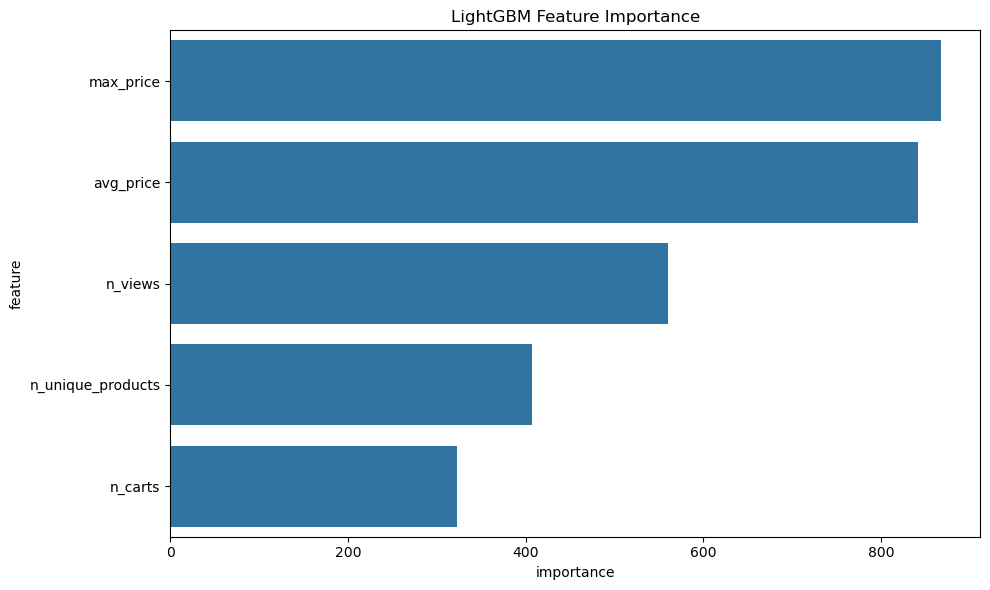

In [65]:
lgbm_model = pipe_lgbm.named_steps["model"]
feature_names = x.columns
importances = lgbm_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feat_imp)
plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

In [66]:
import joblib
import os

In [69]:
os.makedirs("ecommerce_model/trained_models",exist_ok = True)
joblib.dump(pipe_lgbm, "ecommerce_model/trained_models/lgbm_pipeline.pkl")
print("Model saved successfully")

Model saved successfully
